# H2 — Retrasos de Envío vs Calificación del Cliente

**Hipótesis:** Los retrasos en la entrega (fecha real > fecha estimada) impactan
negativamente la calificación promedio de satisfacción del cliente.

**Herramientas:** PySpark (date functions, window functions, joins) · Matplotlib · Seaborn

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

HDFS         = os.environ.get('HADOOP_NAMENODE', 'hdfs://namenode:8020')
SPARK_MASTER = os.environ.get('SPARK_MASTER', 'local[*]')
DATA_PATH    = f'{HDFS}/data/olist'
OUT          = '/home/jovyan/work/outputs/graficas'
os.makedirs(OUT, exist_ok=True)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 130

In [2]:
spark = SparkSession.builder \
    .appName('H2_Envio_Calificacion') \
    .master(SPARK_MASTER) \
    .config('spark.hadoop.fs.defaultFS', HDFS) \
    .config('spark.sql.shuffle.partitions', '8') \
    .getOrCreate()
spark.sparkContext.setLogLevel('WARN')

26/04/17 17:35:29 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Using Spark's default log4j profile: org/apache/spark/log4j-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


In [3]:
orders  = spark.read.csv(f'{DATA_PATH}/orders.csv',        header=True, inferSchema=True)
reviews = spark.read.csv(f'{DATA_PATH}/order_reviews.csv', header=True, inferSchema=True)

analysis = orders \
    .filter(F.col('order_status') == 'delivered') \
    .filter(F.col('order_delivered_customer_date').isNotNull()) \
    .withColumn('dias_retraso',
        F.datediff(
            F.to_timestamp('order_delivered_customer_date'),
            F.to_timestamp('order_estimated_delivery_date')
        )
    ) \
    .withColumn('con_retraso', F.when(F.col('dias_retraso') > 0, 1).otherwise(0)) \
    .join(reviews.select('order_id', 'review_score'), 'order_id')

analysis.cache()
print(f'Órdenes analizadas: {analysis.count():,}')

Órdenes analizadas: 62,802


### Gráfica 1 — Score promedio: Con retraso vs Sin retraso

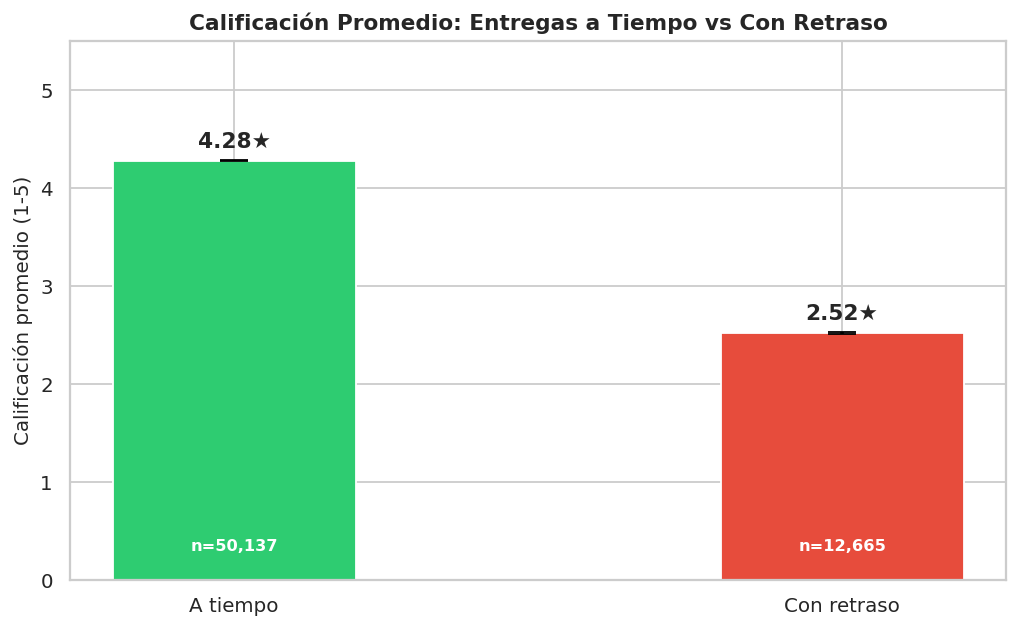

   etiqueta  score_promedio  total_ordenes
   A tiempo        4.277480          50137
Con retraso        2.521121          12665


In [4]:
comp = analysis.groupBy('con_retraso').agg(
    F.avg('review_score').alias('score_promedio'),
    F.count('order_id').alias('total_ordenes'),
    F.stddev('review_score').alias('score_std')
).toPandas()
comp['etiqueta'] = comp['con_retraso'].map({0: 'A tiempo', 1: 'Con retraso'})
comp = comp.sort_values('con_retraso')

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#2ecc71', '#e74c3c']
bars = ax.bar(comp['etiqueta'], comp['score_promedio'], color=colors, width=0.4, edgecolor='white')
ax.errorbar(comp['etiqueta'], comp['score_promedio'],
            yerr=comp['score_std'] / np.sqrt(comp['total_ordenes']),
            fmt='none', color='black', capsize=8, linewidth=2)
ax.bar_label(bars, labels=[f'{v:.2f}★' for v in comp['score_promedio']],
             padding=5, fontsize=12, fontweight='bold')
ax.set_ylim(0, 5.5)
ax.set_ylabel('Calificación promedio (1-5)', fontsize=11)
ax.set_title('Calificación Promedio: Entregas a Tiempo vs Con Retraso', fontsize=12, fontweight='bold')
for i, (_, row) in enumerate(comp.iterrows()):
    ax.text(i, 0.3, f'n={row["total_ordenes"]:,}', ha='center', fontsize=9, color='white', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT}/H2_calificacion_retraso.png', bbox_inches='tight')
plt.show()
print(comp[['etiqueta', 'score_promedio', 'total_ordenes']].to_string(index=False))

### Gráfica 2 — Distribución de scores por grupo (%)

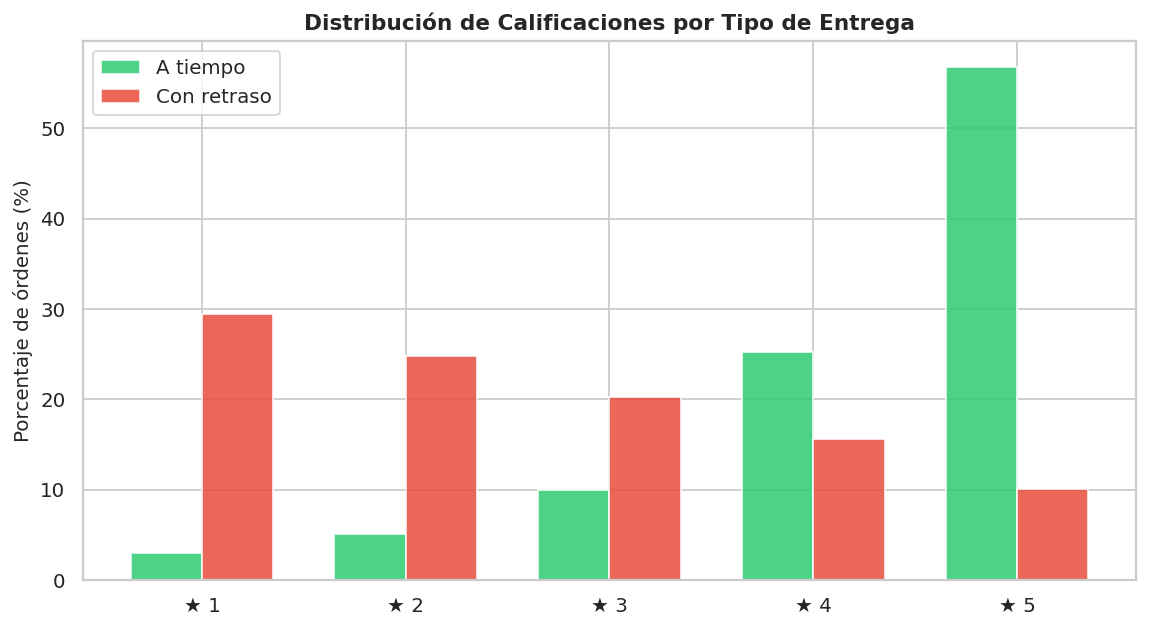

In [5]:
dist = analysis.groupBy('con_retraso', 'review_score').count().toPandas()
dist['etiqueta'] = dist['con_retraso'].map({0: 'A tiempo', 1: 'Con retraso'})
dist_pivot = dist.pivot(index='review_score', columns='etiqueta', values='count').fillna(0)
dist_pct   = dist_pivot.div(dist_pivot.sum()) * 100

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(dist_pct.index))
w = 0.35
ax.bar(x - w/2, dist_pct['A tiempo'],    w, label='A tiempo',    color='#2ecc71', alpha=0.85)
ax.bar(x + w/2, dist_pct['Con retraso'], w, label='Con retraso', color='#e74c3c', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([f'★ {i}' for i in dist_pct.index], fontsize=11)
ax.set_ylabel('Porcentaje de órdenes (%)', fontsize=11)
ax.set_title('Distribución de Calificaciones por Tipo de Entrega', fontsize=12, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(f'{OUT}/H2_distribucion_scores.png', bbox_inches='tight')
plt.show()

### Gráfica 3 — Score promedio según magnitud del retraso

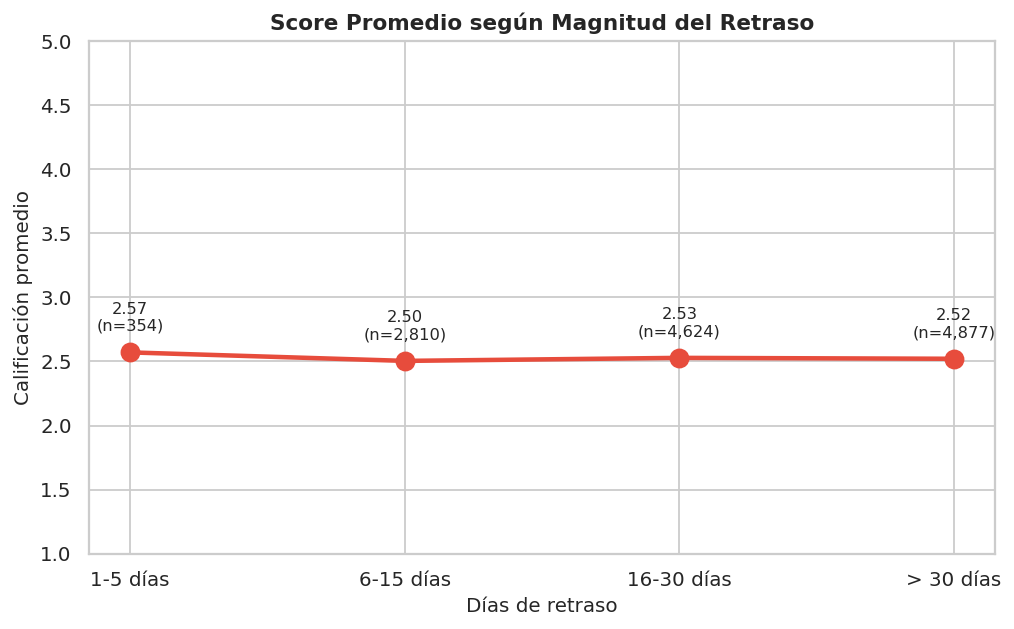

In [6]:
late = analysis.filter(F.col('con_retraso') == 1) \
    .withColumn('bucket_retraso',
        F.when(F.col('dias_retraso') <= 5,  '1-5 días')
         .when(F.col('dias_retraso') <= 15, '6-15 días')
         .when(F.col('dias_retraso') <= 30, '16-30 días')
         .otherwise('> 30 días')
    ) \
    .groupBy('bucket_retraso').agg(
        F.avg('review_score').alias('score_promedio'),
        F.count('order_id').alias('n')
    ).toPandas()

orden = {'1-5 días': 0, '6-15 días': 1, '16-30 días': 2, '> 30 días': 3}
late['orden'] = late['bucket_retraso'].map(orden)
late = late.sort_values('orden')

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(late['bucket_retraso'], late['score_promedio'],
        'o-', color='#e74c3c', linewidth=2.5, markersize=10)
for _, row in late.iterrows():
    ax.annotate(f"{row['score_promedio']:.2f}\n(n={row['n']:,})",
                (row['bucket_retraso'], row['score_promedio']),
                textcoords='offset points', xytext=(0, 12), ha='center', fontsize=9)
ax.set_ylim(1, 5)
ax.set_ylabel('Calificación promedio', fontsize=11)
ax.set_xlabel('Días de retraso', fontsize=11)
ax.set_title('Score Promedio según Magnitud del Retraso', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT}/H2_score_vs_dias_retraso.png', bbox_inches='tight')
plt.show()

### Conclusión H2

In [7]:
scores = comp.set_index('etiqueta')['score_promedio']
diff   = scores['A tiempo'] - scores['Con retraso']
print(f'Score promedio a tiempo:    {scores["A tiempo"]:.2f}')
print(f'Score promedio con retraso: {scores["Con retraso"]:.2f}')
print(f'Diferencia:                 {diff:.2f} puntos')
print()
print('CONCLUSIÓN: La hipótesis SE CONFIRMA.')
print(f'  Los retrasos reducen la calificación ~{diff:.1f} puntos (escala 1-5).')
print('  Mayor el retraso → menor la calificación (tendencia monotónica).')

Score promedio a tiempo:    4.28
Score promedio con retraso: 2.52
Diferencia:                 1.76 puntos

CONCLUSIÓN: La hipótesis SE CONFIRMA.
  Los retrasos reducen la calificación ~1.8 puntos (escala 1-5).
  Mayor el retraso → menor la calificación (tendencia monotónica).


In [8]:
spark.stop()